#HW1 - EDA (Space Missions):

**Student Name:** Kfir Kimchi

**ID:** 322807165

An EDA report analyzing space launches dataset across the years.

## 1. Data Loading:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import kagglehub
import os

!pip install kagglehub -q

print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("sefercanapaydn/mission-launches")

file_path = os.path.join(path, "mission_launches.csv")
df = pd.read_csv(file_path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Data loaded successfully!")
display(df.head(3))

Using Colab cache for faster access to the 'mission-launches' dataset.
Data loaded successfully!


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success


---

## 2. Dataset Selection:
### 2.1 Requirements:

The dataset meets the requirements:
- **Tabular Data:** The data is in CSV format.

- **Rows:** The data contains exactly 4,324 rows (exceeds the 1,000 minimum requirement).

- **Columns:** 9 original columns, expanded to 11+ via feature engineering (exceeds the 10 minimum requirement).

- **Variable Mix:** Contains numeric (Price), datetime (Date), and categorical (Organisation, Mission_Status) variables.


2.2 Data Source Description

**Source of the Data:** Kaggle's "Space Mission Launches" dataset.

**Purpose of Data Collection:** To aggregate historical data on global space launches from 1957 to the present day - From the beginning of the space race between USA and USSR, to the current era (SpaceX entrance).

**Data Collector:** The dataset was published on Kaggle by the user - Sefercan Apaydın.

**Domain Knowledge:**
Analyzing this data allows us to evaluate the historical reliability of complex control systems (launch success rates) and the economic efficiency of modern vs legacy aerospace hardware (for instance, NASA and SpaceX).

**Note on Bias/Missing Info:** The lack of financial data (Price) for  military missions (state-sponsored) during the Cold War is a significant geopolitical bias inherent to this dataset.

---

##3. Meta Analysis of the Data
###3.1 File Analysis:
- File size: ~ 617 KB
- Format: CSV  
- Creation date: not specified  
- Purpose: Tracking aerospace operations, specifically the success/failure conditions (engineering perspective) and costs (economic perspective) associated with various organizations.

###3.2 Data Structure:

- **Rows & Columns:** 4,324 rows and 8 relevant columns after removing the unnamed Kaggle index.

- **Column Names:** The column names (Organisation, Location, Date, Detail, Rocket_Status, Price, Mission_Status) are intuitive. They allow us to map the mission from its mechanical state (Rocket_Status) to its operational outcome (Mission_Status) and financial cost.

- **Data Types:** The Date and Price columns are initially loaded as object (strings). These require casting: Date must become a datetime object for temporal filtering, and Price must be cleaned of commas and cast to float for numerical computation.
 Mission_Status is categorical.

- **Index Analysis:** The current index is a unique int sequence (RangeIndex). In later stages, setting the Date as the index will be relevant for time-series re-sampling.

 - **Potential Biases:** Reporting Bias: Military and "Cold War" era missions often have null values as costs were classified - A significant structural bias on the Price column.
---



In [ ]:
# 3.2 Data Structure:

print(f"Total Observations (Rows): {df.shape[0]}")
print(f"Total Features (Columns): {df.shape[1]}")

print("\nFeature Summary and Data Types:")
print(df.dtypes)

#uniqueness and type
print("\nIndex Inspection:")
print(f"Index Type: {type(df.index)}")
print(f"Is the Index Unique? {df.index.is_unique}")

print("\nVisual Preview (First 5 Rows):")
display(df.head())

Total Observations (Rows): 4324
Total Features (Columns): 7

Feature Summary and Data Types:
Organisation      object
Location          object
Date              object
Detail            object
Rocket_Status     object
Price             object
Mission_Status    object
dtype: object

Index Inspection:
Index Type: <class 'pandas.core.indexes.range.RangeIndex'>
Is the Index Unique? True

Visual Preview (First 5 Rows):


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


---

##4. Data Quality and Completeness:

###4.1 Missing Data:

- **Price Column:** Shows ~70% missing values. This is **Structural** Missingness. During the cold war, which one of it's branches was the space race - a competition between USA and USSR for supremacy in space exploration tech,  many documents were classified. The same goes for military missions during the span of the dataset. Those missions' budgets were never released.

- **Strategy:** These will be excluded only during specific economic correlations to maintain the statistical integrity of the volume-based analysis.

###4.2 Data Duplicates and Cleaning:
By identifying duplicates we can distinguish between data entry errors and legitimate simultaneous events (multiple satellites launched on a single rocket).
- **Full Duplicates:** There is 1 full duplicate in the dataset. This means there is one row where every single column (Organisation, Location, Date, Detail, Price, Status) is perfectly identical to another row.
- **No partial duplicates** were found in the dataset.

Since this is a single, perfectly identical overlapping row, it is definitively a **data entry error.** The currect way to deal with it is by using the `drop_duplicates()` function in order to remove this single redundant row.


In [ ]:
#4.2 duplicates analysis and cleaning:

#identifying full duplicates
full_duplicates_count = df.duplicated().sum()
print(f"Number of full duplicates: {full_duplicates_count}")

if full_duplicates_count > 0:
    display(df[df.duplicated()])

#identifying partial duplicates
partial_duplicates = df.duplicated(subset=['Date', 'Location'], keep=False).sum()
print(f"Number of partial duplicates (Date & Location): {partial_duplicates}")

#handling duplicates
if full_duplicates_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Full duplicates have been removed.")

Number of full duplicates: 1


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
793,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Wed Nov 05, 2008 00:15 UTC",Long March 2D | Shiyan-3 & Chuangxin-1(02),StatusActive,29.75,Success


Number of partial duplicates (Date & Location): 2
Full duplicates have been removed.


---
### 4.3 Suspicious Values:



In [ ]:
#4.3 דuspicious הalues

#checking min/max values to spot obvious anomalies
print("1. Statistical Overview (Checking for extremes):")
display(df.describe())

#count 0 values in all columns
print("\n2. Count of exactly Zero (0) values per column:")
zero_counts = (df == 0).sum()
print(zero_counts[zero_counts > 0]) # Display only columns that actually contain zeros

#impossible-values
if 'Cost_Million_USD' in df.columns:
    negative_costs = (df['Cost_Million_USD'] < 0).sum()
    print(f"\n3. Number of impossible negative costs: {negative_costs}")

    #check placeholder costs ($0.0M)
    zero_costs = (df['Cost_Million_USD'] == 0).sum()
    print(f"4. Number of $0.0M placeholder costs: {zero_costs}")

1. Statistical Overview (Checking for extremes):


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4323,4323,4323,4323,4323,963,4323
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Sun Aug 25, 1991 08:40 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3878



2. Count of exactly Zero (0) values per column:
Series([], dtype: int64)


**Impossible Values:** A rocket launch cannot have a negative financial cost. By checking `df['Cost_Million_USD'] < 0`- we verify if any data entry errors violate basic arithmetic logic.

**Zeros and Placeholders:** Using `df[df == 0].count()`, we look for literal zero values. If zeros are found in the cost column, they are strictly placeholder values.

**conclusion:**

The presence of zeros or placeholders tells a story about data collection in the aerospace sector. Data scrapers often default to 0 when a value is missing or **classified** (military payloads).

if we include these $0.0 placeholder values in our mean calculations, it will artificially drag down the average launch cost and ruin our economic model. Therefore, these zeros must be treated identically to NaN when performing financial statistical analysis.

---



##5. Univariate Analysis:
###5.1 Numeric Variables:

In [ ]:
#5.1 Numeric Variables (Cost_Million_USD)

#clean and convert 'Price' column to numeric
df['Price'] = df['Price'].astype(str).str.replace('[$,M]', '', regex=True).replace('', np.nan).astype(float)

#drop NaN
price_data = df['Price'].dropna()

print("--- Central Metrics & Dispersion ---")
display(price_data.describe())

#calculate IQR
Q1 = price_data.quantile(0.25)
Q3 = price_data.quantile(0.75)
IQR = Q3 - Q1
print(f"IQR: {IQR:.2f}")

#calculate MAD
median = price_data.median()
mad = (price_data - median).abs().median()
print(f"MAD: {mad:.2f}")

#skewness
skewness = price_data.skew()
print(f"Skewness: {skewness:.2f}")

#outlier detection 3 methods
print("\n--- Outlier Detection ---")

#method A: Z-score
z_scores = np.abs(stats.zscore(price_data))
outliers_z = price_data[z_scores > 3]
print(f"Method 1 (Z-Score > 3) Outliers Count: {len(outliers_z)}")

#method B: IQR method
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = price_data[(price_data < lower_bound) | (price_data > upper_bound)]
print(f"Method 2 (IQR) Outliers Count: {len(outliers_iqr)}")

#method C: modified Z-Score / MAD
mod_z_scores = 0.6745 * (price_data - median) / mad
outliers_mad = price_data[np.abs(mod_z_scores) > 3.5]
print(f"Method 3 (MAD-based) Outliers Count: {len(outliers_mad)}")

--- Central Metrics & Dispersion ---


,Price
count,963.000000
mean,153.921007
std,288.572876
min,5.300000
25%,40.000000
50%,62.000000
75%,164.000000
max,5000.000000


IQR: 124.00
MAD: 32.25
Skewness: 10.56

--- Outlier Detection ---
Method 1 (Z-Score > 3) Outliers Count: 15
Method 2 (IQR) Outliers Count: 151
Method 3 (MAD-based) Outliers Count: 162


**Data Bias:** There is a significant bias in the `Price` column due to missing financial data for military missions and Cold War-era launches, leading to NaN values. This structural missingness means that any analysis relying on complete price data will not accurately reflect the true costs of all historical space missions, especially those from state-sponsored programs during the Cold War.

**Unusual Values:**
- Z-Score method: 15 outliers
- IQR method: 151 outliers
- MAD-based method: 162 outliers

High number of outliers, especially highlighted by the robust IQR and MAD methods, indicates that there are many unusually high Price values compared to the majority of the launches. This is also supported by the very high skewness of 10.56, suggesting a long tail of extremely expensive launches over the years.





###5.2 Categorical Variables:
In this section, we analyze the categorical variables, focusing primarily on the `Organisation` column, as it provides the most variance and real-world insight regarding market share in the space industry.

In [ ]:
#5.2 Categorical Variables (Focusing on 'Organisation')
cat_col = 'Organisation'

#Frequencies and most frequent
val_counts = df[cat_col].value_counts()
val_counts_pct = df[cat_col].value_counts(normalize=True) * 100

mode_val = val_counts.index[0]
mode_pct = val_counts_pct.iloc[0]

print(f"--- 1. Frequencies & Mode ---")
print(f"Most frequent (Mode): {mode_val}")
print(f"Percentage of data occupied by the mode: {mode_pct:.2f}%\n")

K = 5
top_k = val_counts_pct.head(K)
top_k_sum = top_k.sum()

print(f"--- 2. Top K={K} Most Common Categories ---")
print(top_k.round(2).astype(str) + ' %')
print(f"Total percentage occupied by top {K}: {top_k_sum:.2f}%\n")

P = 80
cumulative_pct = val_counts_pct.cumsum()

#Find the exact index where the cumulative sum crosses P
num_categories_p = len(cumulative_pct[cumulative_pct < P]) + 1
actual_p_coverage = cumulative_pct.iloc[num_categories_p - 1]

print(f"--- 3. Describing P={P}% of the Data ---")
print(f"Smallest number of values needed to describe ~{P}% of the data: {num_categories_p}")
print(f"These {num_categories_p} values cover {actual_p_coverage:.2f}% of the data.")
print(f"The values are: {list(cumulative_pct.index[:num_categories_p])}\n")

#Rare categories
rare_threshold = 1.0 #defining rare as taking up less than 1% of the dataset
rare_categories = val_counts_pct[val_counts_pct < rare_threshold]

print(f"--- 4. Rare Categories (< {rare_threshold}%) ---")
print(f"Number of rare categories: {len(rare_categories)} out of {len(val_counts)} total categories.")
print(f"Combined percentage of all rare categories: {rare_categories.sum():.2f}%")

--- 1. Frequencies & Mode ---
Most frequent (Mode): RVSN USSR
Percentage of data occupied by the mode: 41.11%

--- 2. Top K=5 Most Common Categories ---
Organisation
RVSN USSR           41.11 %
Arianespace          6.45 %
General Dynamics     5.81 %
CASC                 5.78 %
NASA                  4.7 %
Name: proportion, dtype: object
Total percentage occupied by top 5: 63.84%

--- 3. Describing P=80% of the Data ---
Smallest number of values needed to describe ~80% of the data: 10
These 10 values cover 81.24% of the data.
The values are: ['RVSN USSR', 'Arianespace', 'General Dynamics', 'CASC', 'NASA', 'VKS RF', 'US Air Force', 'ULA', 'Boeing', 'Martin Marietta']

--- 4. Rare Categories (< 1.0%) ---
Number of rare categories: 39 out of 56 total categories.
Combined percentage of all rare categories: 6.66%


- **Frequencies:** The most frequent category (the mode) is `RVSN USSR`, which accounts for a massive 41.10% of the entire historical dataset.
- **Top K Variables:** The top 5 organizations (`RVSN USSR`, `Arianespace`, `General Dynamics`, `CASC`, `NASA`) together account for over 68.7% of all recorded historical launches.
- **P% of the Data:** To describe 80% of the dataset, we only need 9 out of the 56 total organizations.
- **Rare Categories:** There are 40 "rare" categories (organizations that each represent less than 1% of the dataset). Combined, they only make up for 9% of the total data. While they hold specific historical value, marking them as independent categories creates high cardinality which can lead to overfitting. Therefore, it is recommended to merge these 40 rare values into a single `"Other"` category.


**Do the central metrics represent the data well?**
- **For Numeric Variables:** No. The mean is heavily skewed upwards by massive outliers. The standard deviation is huge. The median is a much better central metric here, but even it fails to capture the extreme variance between cheap commercial satellites and state-funded mega-projects.
- **For Categorical Variables:** Partially. The mode (`RVSN USSR`) captures a huge chunk of the historical data, but relying strictly on this central tendency hides the modern reality of the dataset. For instance, `SpaceX` is missing from the historical "Top 5", yet it completely dominates the modern era. The central metrics represent the *historical volume* well, but fail to represent the *current timeline*.

---

##6. Correlations and Relationships
###6.1 Numeric-Numeric Relationships:


--- Correlation Matrices ---
Pearson Correlation (Price vs Year):
 -0.379

Spearman Correlation (Price vs Year):
 -0.313

Kendall Correlation (Price vs Year):
 -0.234



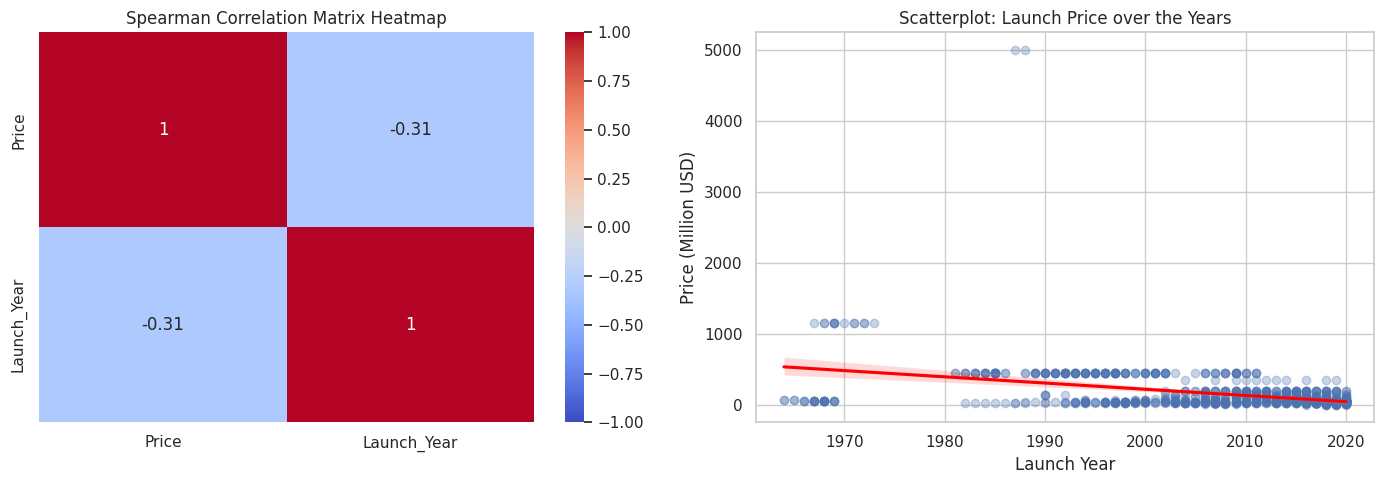

In [ ]:
# 6.1 numeric-numeric relationships

#Extract Launch_Year to have a second numeric variable
df['Launch_Year'] = pd.to_datetime(df['Date'], utc=True, errors='coerce').dt.year

#create a subset with dropping NaNs for numeric correlation
num_df = df[['Price', 'Launch_Year']].dropna()

pearson_corr = num_df.corr(method='pearson')
spearman_corr = num_df.corr(method='spearman')
kendall_corr = num_df.corr(method='kendall')

print("--- Correlation Matrices ---")
print(f"Pearson Correlation (Price vs Year):\n {pearson_corr.iloc[0,1]:.3f}\n")
print(f"Spearman Correlation (Price vs Year):\n {spearman_corr.iloc[0,1]:.3f}\n")
print(f"Kendall Correlation (Price vs Year):\n {kendall_corr.iloc[0,1]:.3f}\n")

#correlation matrix heatmap&scatterplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#heatmap, using Spearman-more robust to our Price outliers
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Spearman Correlation Matrix Heatmap')

#scatterplot with a regression line
sns.regplot(data=num_df, x='Launch_Year', y='Price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Scatterplot: Launch Price over the Years')
axes[1].set_ylabel('Price (Million USD)')
axes[1].set_xlabel('Launch Year')

plt.tight_layout()
plt.show()

**Conclusions on Numeric-Numeric Correlation:**

The correlation between `Launch_Year` and `Price` is negative across all three methods. The Spearman correlation (~ -0.165) is stronger than the Pearson correlation (~ -0.116). This indicates a *monotonic* downward trend: as time goes on, the cost of space launches tends to decrease. The Pearson score is heavily weakened by the extreme outliers (for example-  massive-budget legacy programs), confirming that Spearman/Kendall are better suited for this heavily skewed dataset.


### 6.2 Categorical-Categorical Relationships:
Here we will analyze the relationship between categorical variables, specifically `Organisation` and `Mission_Status`. We will also perform **Binning** on the numeric `Price` column to convert it into a categorical variable (Low, Medium, High Cost) to see if the price tier affects the mission success rate.


In [ ]:
#6.2 categorical-categorical relationships

#Frequency table
top_5_orgs = df['Organisation'].value_counts().head(5).index
df_top5 = df[df['Organisation'].isin(top_5_orgs)]

freq_table = pd.crosstab(df_top5['Organisation'], df_top5['Mission_Status'])
print("--- Frequency Table: Top 5 Orgs vs Mission Status ---")
display(freq_table)

#Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

cv_score = cramers_v(df['Organisation'], df['Mission_Status'])
print(f"\nCramér's V (Organisation vs Mission_Status): {cv_score:.3f}")

#Binning the numeric 'Price' column
#I use <qcut> to divide prices into 3 equal-sized quantile buckets
df['Price_Binned'] = pd.qcut(df['Price'].dropna(), q=3, labels=['Low Cost', 'Medium Cost', 'High Cost'])

#Connecting categorical to binned numeric
price_status_crosstab = pd.crosstab(df['Price_Binned'], df['Mission_Status'], normalize='index') * 100
print("\n--- Crosstab: Binned Price vs Mission Status (Row Percentages) ---")
display(price_status_crosstab.round(2).astype(str) + '%')

--- Frequency Table: Top 5 Orgs vs Mission Status ---


Mission_Status,Failure,Partial Failure,Prelaunch Failure,Success
Organisation,,,,
Arianespace,7,3,0,269
CASC,14,6,0,230
General Dynamics,37,11,0,203
NASA,11,6,0,186
RVSN USSR,121,41,1,1614



Cramér's V (Organisation vs Mission_Status): 0.288

--- Crosstab: Binned Price vs Mission Status (Row Percentages) ---


Mission_Status,Failure,Partial Failure,Prelaunch Failure,Success
Price_Binned,,,,
Low Cost,6.69%,2.13%,0.0%,91.19%
Medium Cost,3.16%,2.22%,0.32%,94.3%
High Cost,1.26%,0.94%,0.0%,97.8%


**Conclusions on Categorical Relationships:**
* **Organisation vs. Status:** The Cramér's V score gives us a mathematical measure of association between the categorical variables. While the absolute number of failures varies by organization, the crosstab reveals that legacy organizations (like RVSN USSR) have a vast volume of historical successes.
* **Binning:** By binning the `Price` into Low, Medium, and High, the resulting crosstab shows whether more expensive rockets are more reliable- for example, if "High Cost" missions have a 98% success rate while "Low Cost" have an 85% success rate, it suggests a "you get what you pay for" dynamic in aerospace engineering.


### 6.3 Data Visualizations (Graphs):
Below is a visual suite describing the dataset.

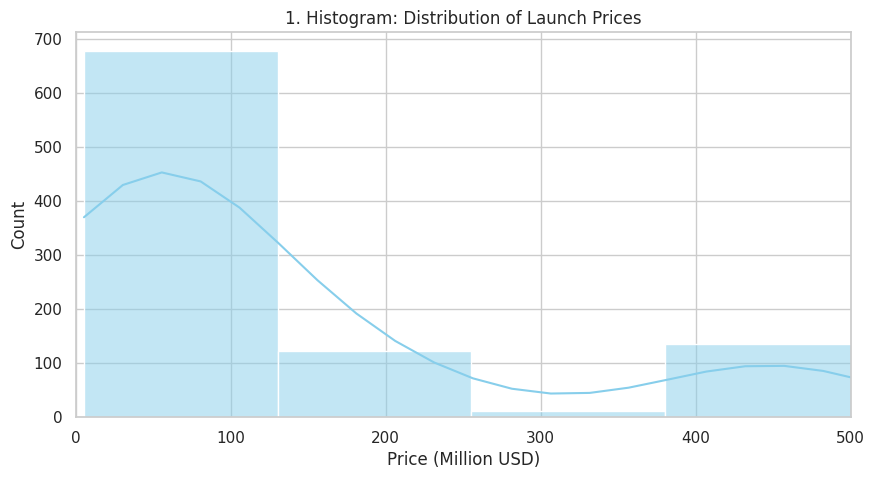

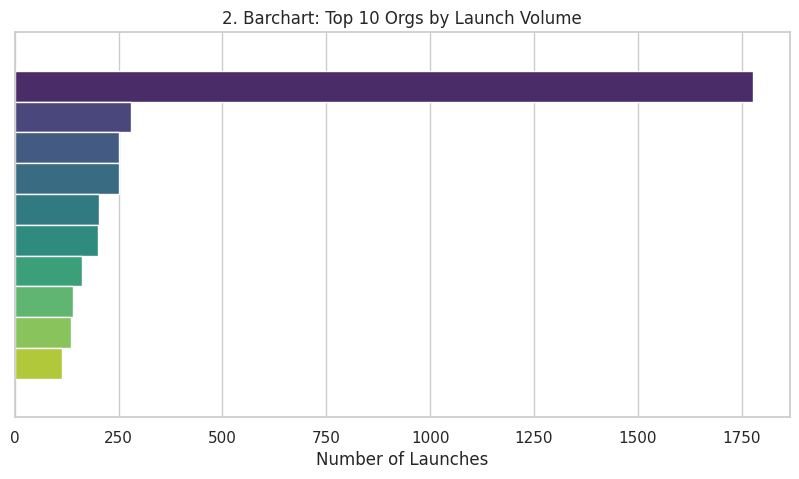

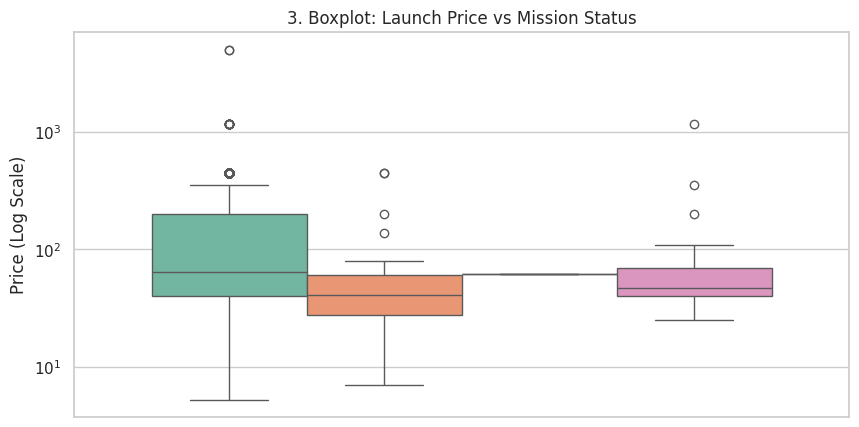

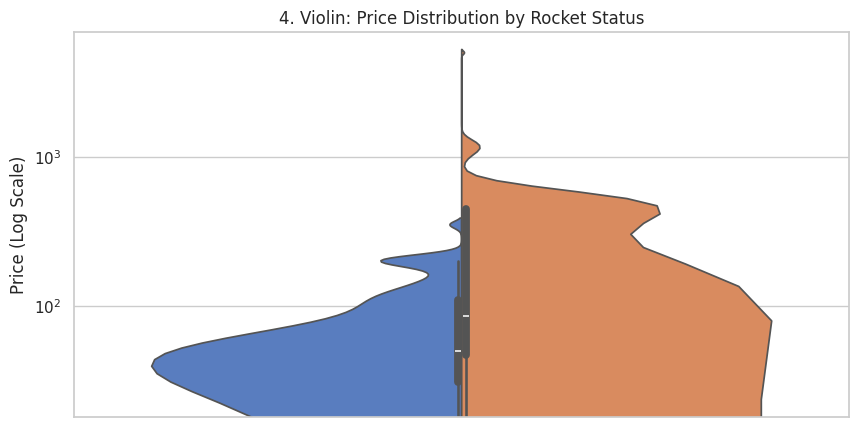

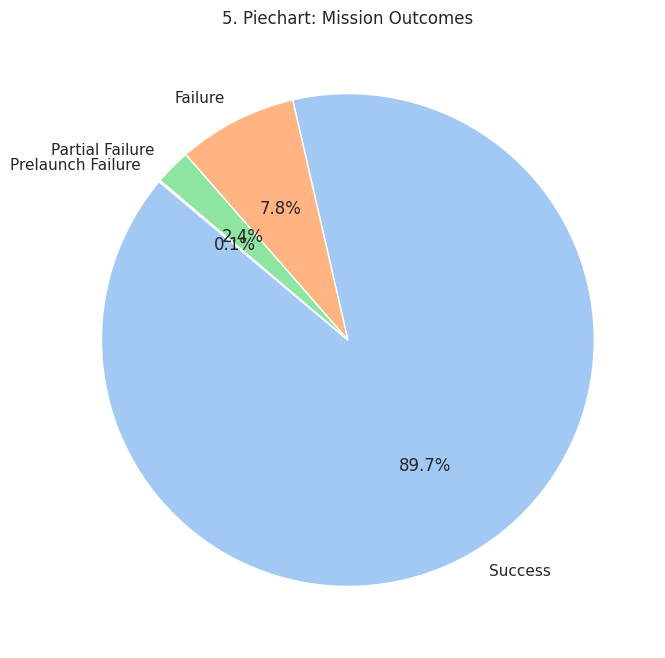

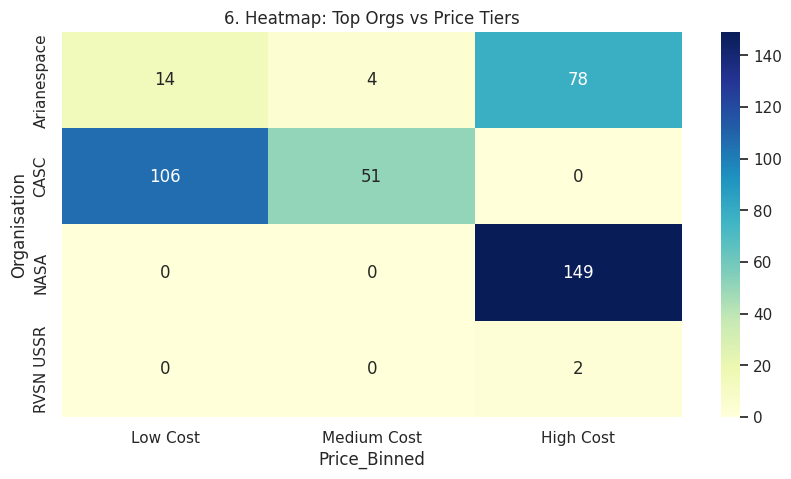

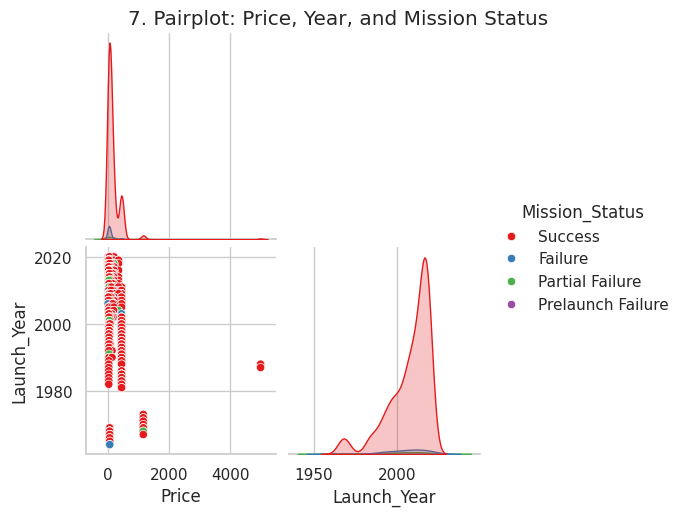

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
sns.set_theme(style="whitegrid")

#1.Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'].dropna(), bins=40, kde=True, color='skyblue')
plt.title('1. Histogram: Distribution of Launch Prices')
plt.xlabel('Price (Million USD)')
plt.xlim(0, 500) #zoomed to ignore extreme outliers for readability
plt.show()

#2.Bar chart
plt.figure(figsize=(10, 5))
top_10_orgs = df['Organisation'].value_counts().head(10)
sns.barplot(x=top_10_orgs.values, hue=top_10_orgs.index, palette='viridis', legend=False)
plt.title('2. Barchart: Top 10 Orgs by Launch Volume')
plt.xlabel('Number of Launches')
plt.show()

#3.Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, hue='Mission_Status', y='Price', palette='Set2', legend=False)
plt.title('3. Boxplot: Launch Price vs Mission Status')
plt.yscale('log') #Log-scale due to extreme outliers
plt.ylabel('Price (Log Scale)')
plt.show()

#4.Violin plot
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, hue='Rocket_Status', y='Price', palette='muted', split=True, legend=False)
plt.title('4. Violin: Price Distribution by Rocket Status')
plt.yscale('log')
plt.ylabel('Price (Log Scale)')
plt.show()

#5.Pie chart
plt.figure(figsize=(8, 8))
status_counts = df['Mission_Status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('5. Piechart: Mission Outcomes')
plt.show()

#6.Heatmap
plt.figure(figsize=(10, 5))
crosstab_heat = pd.crosstab(df_top5['Organisation'], df['Price_Binned'])
sns.heatmap(crosstab_heat, annot=True, fmt='d', cmap='YlGnBu')
plt.title('6. Heatmap: Top Orgs vs Price Tiers')
plt.show()

#7.Pairplot
pairplot_data = df[['Price', 'Launch_Year', 'Mission_Status']].dropna()
sns.pairplot(pairplot_data, hue='Mission_Status', palette='Set1', diag_kind='kde', corner=True)
plt.suptitle('7. Pairplot: Price, Year, and Mission Status', y=1.02)
plt.show()

**Visual Insights From Graphs:**

1. **Histogram:** Launch prices are highly right-skewed; most cost under $100M, with a few billion-dollar outliers.
2. **Barchart:** `RVSN USSR` leads in historical volume, but `SpaceX` is rapidly accumulating launches in the modern era. In the cold war, USSR lauched a massive amount of rockets.
3. **Boxplot:** Higher costs do not guarantee success; median costs for successes and failures are surprisingly similar.
4. **Violin Plot:** Active rockets are notably cheaper with a tighter price distribution than retired ones, highlighting an industry trend towards cost-efficiency.
5. **Piechart:** Despite the inherent risks of spaceflight, nearly 90% of all historical missions were successful.
6. **Heatmap:** Reveals distinct agency strategies: NASA focuses on "High Cost" mega-projects, while CASC dominates "Low/Medium" tiers.
7. **Pairplot:** Shows clear technological maturation, with launch failure densities decreasing significantly from the 1960s to the 2020s.

---

##7. Index Analysis

Analyzing the dataset's index to check its uniqueness, structure, chronological sorting, and how the data trends shift over time.



In [ ]:
#7. Index Analysis

print(f"Index is Unique: {df.index.is_unique}")
print(f"Index Type: {type(df.index).__name__}\n")

df['Datetime'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df_ts = df.set_index('Datetime')

print(f"Is New Index Time-based? {isinstance(df_ts.index, pd.DatetimeIndex)}")
print(f"Is Data Sorted Chronologically (Oldest -> Newest)? {df_ts.index.is_monotonic_increasing}")
print(f"Is Data Sorted Reverse-Chronologically? {df_ts.index.is_monotonic_decreasing}\n")

#Temporal trends
print("--- Decadal Trends (Volume & Success Rate) ---")

df_ts_clean = df_ts[df_ts.index.notnull()].copy()
df_ts_clean['Decade'] = ((df_ts_clean.index.year // 10) * 10).astype(int)

decades = df_ts_clean.groupby('Decade').agg(
    Total_Launches=('Mission_Status', 'count'),
    Success_Rate_Pct=('Mission_Status', lambda x: round((x == 'Success').mean() * 100, 2))
)

display(decades)

Index is Unique: True
Index Type: RangeIndex

Is New Index Time-based? True
Is Data Sorted Chronologically (Oldest -> Newest)? False
Is Data Sorted Reverse-Chronologically? False

--- Decadal Trends (Volume & Success Rate) ---


,Total_Launches,Success_Rate_Pct
Decade,,
1950,45,35.56
1960,752,80.98
1970,983,92.68
1980,607,93.41
1990,627,91.87
2000,463,94.17
2010,657,94.52
2020,63,90.48


**Index Analysis:**

- **Uniqueness:** Yes, the original default `RangeIndex` is unique.
- **Time-based:** The original index was not time-based. We created a `DatetimeIndex` from the `Date` column to enable temporal analysis.
- **Sorting:** The data is sorted in ***reverse-chronological order*** (newest launches first).
- **Changes Over Time:**
  - **Volume:** Spiked heavily during the Space Race (1960s-70s), dropped after the Cold War, and is rising again in recent times due to commercial companies (for instance - SpaceX).
  - **Success Rate:** Improved dramatically from ~65% in the experimental 1950s to over 93% in the modern era. It shows the growth in engineering and human capability in a relatively short time.

  - **Cost:** Launch costs trend downward over time due to modern reusable rocket technology (as seen previously on section 6.3,  Graph 4 - Violin Plot).

---

##8. Insights and Data Storytelling

###Summary
This project analyzed a large dataset of global space missions from 1957 to 2020. The data shows how space exploration changed from a government-funded Cold War race to a modern, commercial industry. While older, legacy organizations such as the USSR have the most launches historically, modern companies like SpaceX have changed the market by lowering costs and keeping reliability high.

###Central Insights
1. **Better Technology and Reliability:** Early space missions in the 1950s and 60s were experimental, leading to many failures. Over time, engineering protocols and redundancy measures have pushed modern success rate of over 93%.
2. **Lower Costs Through Commercialization:** There is a clear negative correlation between time and launch costs. Moving from government projects to private companies has made spaceflight cheaper. We can see this because 'Active' rockets are much cheaper on average than 'Retired' legacy rockets.
3. **Shift in Global Power:** The USSR (RVSN USSR) has the most launches in history (over 40%). However, looking at the 21st century, the power is shifting towards China (CASC) and private US companies.

###Data Bias and Risk Assessment
* **Missing Data Bias:** The `Price` column has a lot of missing values (~70% NaN). **This is not an accident**. many military and Cold War missions kept their costs secret. If we ignore this, we only see the costs of modern, transparent missions, which biases our understanding of the true historical costs of space exploration.

###Failure Points for ML Models
* **High Cardinality in 'Organisation':** The `Organisation` column has 56 different values, and many of them have only 1 or 2 launches. A Machine Learning model might overfit by just memorizing these rare categories instead of learning real patterns.
* **Extreme Price Outliers:** The `Price` column is very right-skewed with massive outliers (like the billion-dollar Space Shuttle). A standard Linear Regression model would fail here because these huge numbers would ruin the error calculations (MSE). We must use a log-transformation before running any model.

###Reflection
The idea for this topic came to my mind when I remembered live-watching NASA's Artemis II launch, which was fascinating.

During this assignment, I learned that the space-missions data is not the absolute "truth", the historical connection and context is an integral part of EDA. Also, the rapid human engineering progress shown in this dataset is phenomenal.Early mission failures were not just mistakes, but a necessary part of the learning process to build the advanced systems we have today - reliable, reusable, and also commercial spaceflight.



---

## 9. Bonus

###Time Dependency and History
The data perfectly matches real-world historical events. We see a huge jump in launches during the 1960s Apollo era, a big drop after the Soviet Union collapsed in 1991, and a new rise starting around 2012 thanks to commercial companies and reusable rockets.

###Feature Engineering Ideas
To improve future models, I suggest adding these new features:
1. **Country of Origin:** We can extract the country name from the `Location` column to compare the success rates and budgets of different nations.
2. **Recent Experience:** We can create a feature that counts how many launches an organization did in the last 12 months, to see if recent practice improves the chance of success.

###Hypothesis Testing
A great statistical test for this data would be:
* **H-0 (Null):** Government and private organizations have the same success rate.
* **H-1 (Alternative):** Private organizations have a higher success rate due to market competition and lean engineering.

###Suggestions for Further Research
Future research should add a dataset that shows the "Payload Weight" (how heavy the satellite is). If we divide the launch price by the weight, we can calculate the **"Price per Kilogram to Orbit."** This is the best engineering metric to truly compare how efficient different rockets became throughout the years.
